In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Base project folder
project_folder = '/content/drive/MyDrive/IS477_PlayerSalaries_Project/'

# Data folder
data_folder = project_folder + 'Data/'


player_salaries_csv_file = data_folder + 'NBA Player Stats and Salaries_2000-2025.csv'

seasons_csv_file = data_folder + 'Season Data(Sheet1).csv'

salaries_df = pd.read_csv(player_salaries_csv_file)

seasons_df = pd.read_csv(seasons_csv_file)

**Salary Data Processing**

In [137]:
salaries_df = pd.read_csv(player_salaries_csv_file)
salaries_df.head()

,Player,Salary,Year,Pos,Age,Team,G,GS,MP,FG,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,Shaquille O'Neal,17142000,2000,C,27,LAL,79,79,40.0,12.1,...,0.524,4.3,9.4,13.6,3.8,0.5,3.0,2.8,3.2,29.7
1,Kevin Garnett,16806000,2000,PF,23,MIN,81,81,40.0,9.4,...,0.765,2.8,9.0,11.8,5.0,1.5,1.6,3.3,2.5,22.9
2,Alonzo Mourning,15004000,2000,C,29,MIA,79,78,34.8,8.3,...,0.711,2.7,6.8,9.5,1.6,0.5,3.7,2.7,3.9,21.7
3,Juwan Howard,15000000,2000,PF,26,WAS,82,82,35.5,6.2,...,0.735,1.6,4.1,5.7,3.0,0.8,0.3,2.7,3.6,14.9
4,Scottie Pippen,14795000,2000,SF,34,POR,82,82,33.5,4.7,...,0.717,1.4,4.9,6.3,5.0,1.4,0.5,2.5,2.5,12.5


In [138]:
contracts_relevant_columns = ["Player", "Salary", "Pos", "Year", "Team"]
salaries_df = salaries_df[contracts_relevant_columns]

In [139]:
salaries_df['Pos'].value_counts()

,count
Pos,
SG,2218
C,2112
PF,2098
PG,1943
SF,1909
PG-SG,29
SF-SG,28
C-PF,24
SG-PG,24


In [140]:
salaries_df[salaries_df['Pos']=='SF-SG']

,Player,Salary,Pos,Year,Team
295,Tyrone Nesby,2990000,SF-SG,2001,WAS
1387,Vince Carter,13281000,SF-SG,2005,NJN
1401,Shandon Anderson,7300000,SF-SG,2005,MIA
1493,Jalen Rose,15694250,SF-SG,2006,NYK
1573,Ruben Patterson,6353200,SF-SG,2006,DEN
1996,Stephen Jackson,6120000,SF-SG,2007,GSW
2724,Jeremy Richardson,238588,SF-SG,2008,ATL
2782,Larry Hughes,12827676,SF-SG,2009,NYK
3000,Thabo Sefolosha,1931160,SF-SG,2009,OKC
3235,Caron Butler,9780970,SF-SG,2010,DAL


In [141]:
salaries_df['Pos'] = salaries_df['Pos'].str.split('-').str[0]

In [142]:
salaries_df['Pos'].unique()

array(['C', 'PF', 'SF', 'PG', 'SG'], dtype=object)

In [143]:
grouped = salaries_df.groupby(['Team', 'Year', 'Pos'])['Salary'].sum().reset_index()
grouped.head()

,Team,Year,Pos,Salary
0,ATL,2000,C,4400000
1,ATL,2000,PF,7318000
2,ATL,2000,PG,1468000
3,ATL,2000,SF,1939000
4,ATL,2000,SG,893000


In [144]:
team_totals = salaries_df.groupby(['Team', 'Year'])['Salary'].sum().reset_index()
team_totals = team_totals.rename(columns={'Salary': 'TeamTotal'})
team_totals.sample(n=10)

,Team,Year,TeamTotal
350,MEM,2003,36122000
136,CLE,2021,126299308
15,ATL,2015,55986562
278,IND,2007,59603348
390,MIA,2017,71555163
699,TOR,2004,44178000
27,BOS,2001,41244000
557,PHI,2001,57459000
157,DAL,2016,71198732
221,GSW,2002,43757000


In [145]:
merged = grouped.merge(team_totals, on=['Team','Year'])
merged['Percent'] = merged['Salary'] / merged['TeamTotal'] * 100

In [146]:
merged

,Team,Year,Pos,Salary,TeamTotal,Percent
0,ATL,2000,C,4400000,16018000,27.469097
1,ATL,2000,PF,7318000,16018000,45.686103
2,ATL,2000,PG,1468000,16018000,9.164690
3,ATL,2000,SF,1939000,16018000,12.105132
4,ATL,2000,SG,893000,16018000,5.574978
...,...,...,...,...,...,...
3726,WAS,2025,C,11245680,166294208,6.762521
3727,WAS,2025,PF,14886012,166294208,8.951612
3728,WAS,2025,PG,47165164,166294208,28.362482
3729,WAS,2025,SF,50312899,166294208,30.255353


<Figure size 1200x700 with 0 Axes>

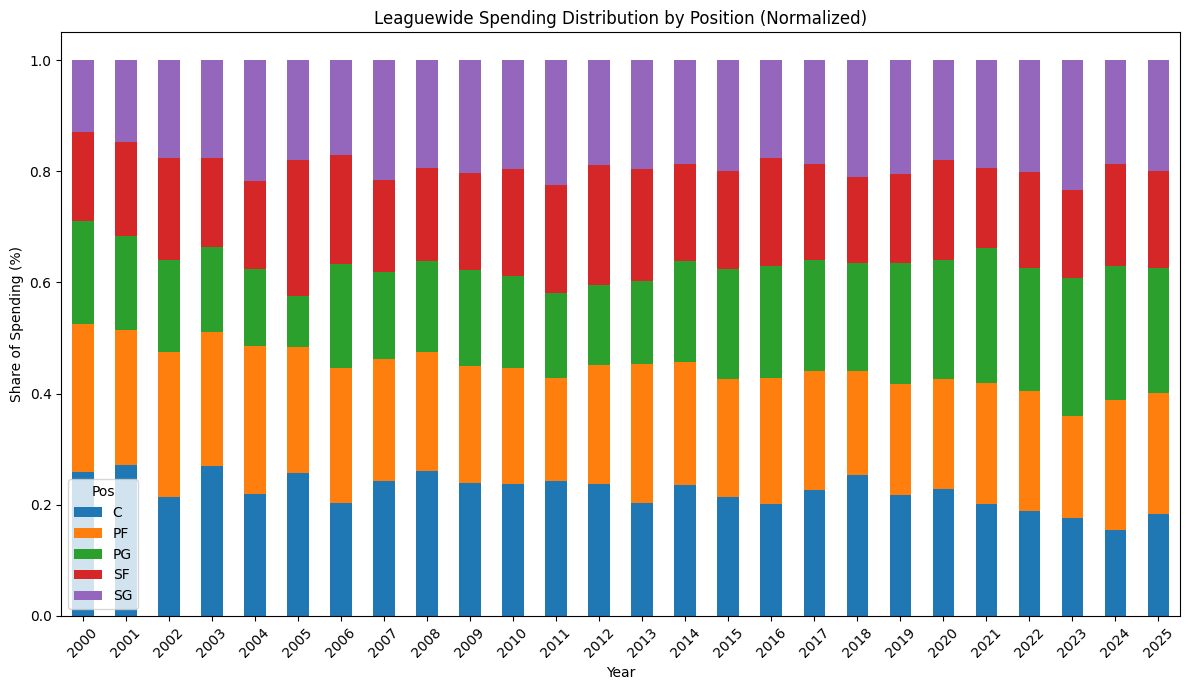

In [148]:
league_spending = (
    merged
    .groupby(['Year', 'Pos'])['Salary']
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

league_spending_pct = league_spending.div(league_spending.sum(axis=1), axis=0)

plt.figure(figsize=(12, 7))

league_spending_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7)
)

plt.xlabel('Year')
plt.ylabel('Share of Spending (%)')
plt.title('Leaguewide Spending Distribution by Position (Normalized)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Season Data Processing**

In [ ]:
seasons_df = seasons_df.iloc[:, :21]
# Only includes regular season stats and playoff W/L Totals

In [ ]:
seasons_df = seasons_df[seasons_df['Year'] > 2004]
# Filter to only include 2005 and beyond

In [ ]:
seasons_df[['PostW', 'PostL']] = seasons_df[['PostW', 'PostL']].fillna(0)
# Fills empty playoff W/L total columns with zero, as these were intentionally left blank since team missed playoffs

In [ ]:
seasons_df['Playoffs'] = (seasons_df[['PostW', 'PostL']].sum(axis=1) > 0).astype(int)
# Creates 0/1 Boolean for whether team made playoffs or not

In [ ]:
seasons_df['Championship'] = (
    seasons_df['Team'].str.contains(r'\?', regex=True)
).astype(int)
# Creates 0/1 Boolean for championship teams, teams that won championship had emoji in team name that was read as question marks

In [ ]:
seasons_df['Team'] = seasons_df['Team'].str.replace('?', '', regex=False)
# Drops aforementioned question marks after championship files created

In [ ]:
seasons_df = seasons_df[seasons_df['Team'].isin(seasons_df['Team'].value_counts()[seasons_df['Team'].value_counts() >= 17].index)]
# Filter for teams that have 17 or more appearances in last 20 years (teams in NBA have shifted over the years)

In [ ]:
seasons_df.isna().sum()
# Succesful check for na values

,0
Season_ID,0
Team,0
Year,0
TR,0
Age,0
W,0
L,0
SRS,0
ORtg,0
rORtg,0


In [ ]:
team_map = {
    'Oklahoma City Thunder': 'OKC',
    'Cleveland Cavaliers': 'CLE',
    'Boston Celtics': 'BOS',
    'Minnesota Timberwolves': 'MIN',
    'Indiana Pacers': 'IND',
    'New York Knicks': 'NYK',
    'Denver Nuggets': 'DEN',
    'Los Angeles Clippers': 'LAC',
    'Houston Rockets': 'HOU',
    'Golden State Warriors': 'GSW',
    'Memphis Grizzlies': 'MEM',
    'Detroit Pistons': 'DET',
    'Sacramento Kings': 'SAC',
    'Los Angeles Lakers': 'LAL',
    'Milwaukee Bucks': 'MIL',
    'Dallas Mavericks': 'DAL',
    'Atlanta Hawks': 'ATL',
    'Chicago Bulls': 'CHI',
    'Orlando Magic': 'ORL',
    'San Antonio Spurs': 'SAS',
    'Phoenix Suns': 'PHO',
    'Portland Trail Blazers': 'POR',
    'Toronto Raptors': 'TOR',
    'Miami Heat': 'MIA',
    'Philadelphia 76ers': 'PHI',
    'Utah Jazz': 'UTA',
    'Washington Wizards': 'WAS'
}
# Creates map to match abbreviate salary team names to full names in season results dataset

In [ ]:
seasons_df

,Season_ID,Team,Year,TR,Age,W,L,SRS,ORtg,rORtg,...,Pace,rPace,FTr,rFTr,TS,rTS,PostW,PostL,Playoffs,Championship
0,1.0,Oklahoma City Thunder,2025.0,15.6,24.8,68.0,14.0,12.7,120.3,5.8,...,100.0,1.2,0.220,-0.023,0.593,0.017,16.0,7.0,1,1
1,2.0,Cleveland Cavaliers,2025.0,11.2,26.6,64.0,18.0,8.8,121.7,7.2,...,99.8,1.0,0.241,-0.002,0.607,0.031,5.0,4.0,1,0
2,3.0,Boston Celtics,2025.0,10.2,28.9,61.0,21.0,8.3,120.6,6.1,...,95.7,-3.1,0.212,-0.031,0.591,0.015,6.0,5.0,1,0
3,4.0,Minnesota Timberwolves,2025.0,9.3,27.2,49.0,33.0,5.2,116.6,2.1,...,97.3,-1.5,0.249,0.006,0.588,0.012,9.0,6.0,1,0
4,5.0,Indiana Pacers,2025.0,8.5,25.8,50.0,32.0,1.7,116.5,2.0,...,99.9,1.1,0.241,-0.002,0.594,0.018,15.0,8.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
572,623.0,New York Knicks,2005.0,-3.0,27.3,33.0,49.0,-2.7,106.2,0.1,...,90.7,-0.2,0.312,-0.012,0.531,0.002,0.0,0.0,0,0
573,624.0,Milwaukee Bucks,2005.0,-3.5,26.9,30.0,52.0,-3.1,106.6,0.5,...,90.8,-0.1,0.339,0.015,0.527,-0.002,0.0,0.0,0,0
575,626.0,Portland Trail Blazers,2005.0,-4.0,27.0,27.0,55.0,-3.5,103.2,-2.9,...,89.8,-1.1,0.303,-0.021,0.524,-0.005,0.0,0.0,0,0
576,627.0,Utah Jazz,2005.0,-4.3,25.7,26.0,56.0,-3.7,104.7,-1.4,...,88.4,-2.5,0.361,0.037,0.522,-0.007,0.0,0.0,0,0


In [ ]:
seasons_df['Team'].unique()

array(['Oklahoma City Thunder', 'Cleveland Cavaliers', 'Boston Celtics',
       'Minnesota Timberwolves', 'Indiana Pacers', 'New York Knicks',
       'Denver Nuggets', 'Los Angeles Clippers', 'Houston Rockets',
       'Golden State Warriors', 'Memphis Grizzlies', 'Detroit Pistons',
       'Sacramento Kings', 'Los Angeles Lakers', 'Milwaukee Bucks',
       'Dallas Mavericks', 'Atlanta Hawks', 'Chicago Bulls',
       'Orlando Magic', 'San Antonio Spurs', 'Phoenix Suns',
       'Portland Trail Blazers', 'Toronto Raptors', 'Miami Heat',
       'Philadelphia 76ers', 'Utah Jazz', 'Washington Wizards'],
      dtype=object)

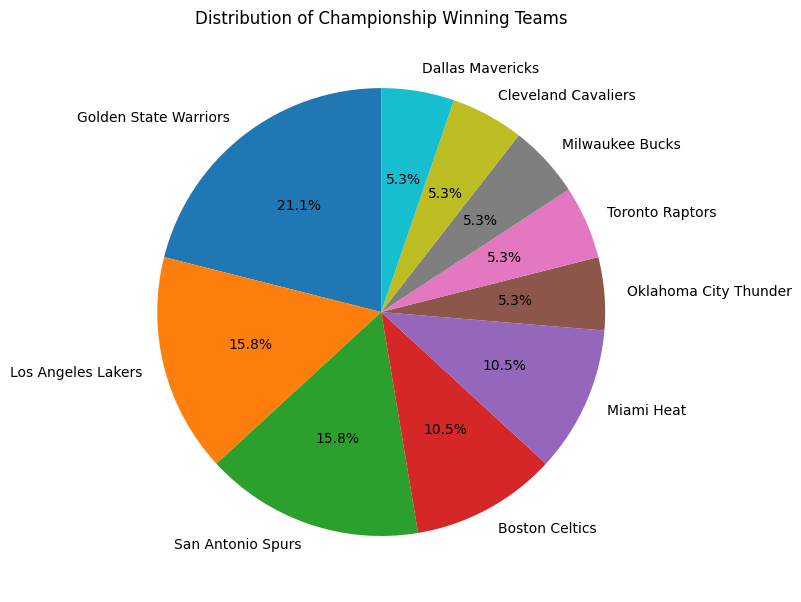

In [ ]:
# Create championship distribution pie chart
champions_df = seasons_df[seasons_df['Championship'] == 1]
counts = champions_df.Team.value_counts()
plt.figure(figsize=(8, 8))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Championship Winning Teams')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

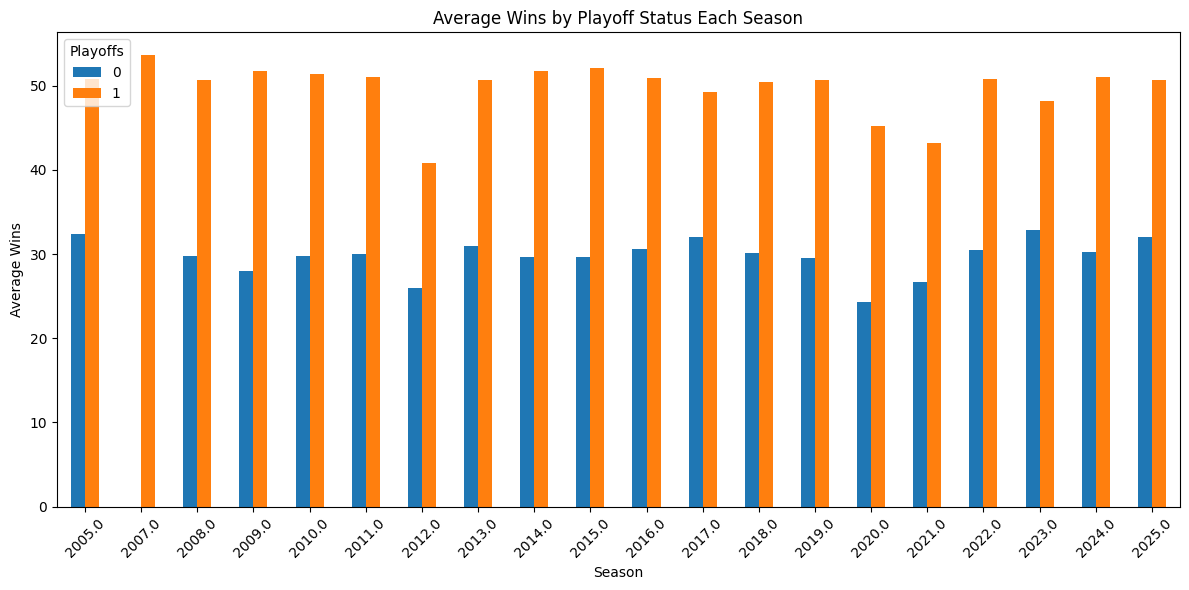

In [ ]:
avg_wins = seasons_df.groupby(['Year', 'Playoffs'])['W'].mean().unstack()

plt.figure(figsize=(12, 6))
avg_wins.plot(kind='bar', figsize=(12, 6))

plt.xlabel('Season')
plt.ylabel('Average Wins')
plt.title('Average Wins by Playoff Status Each Season')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

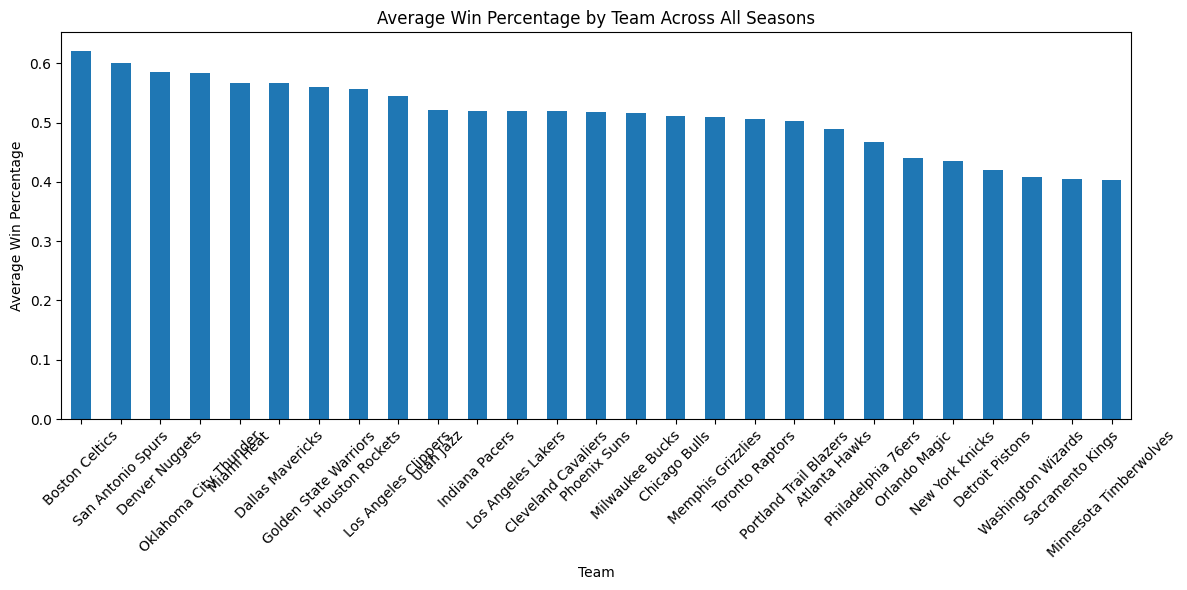

In [ ]:
# Creates winning percentage average across dataset for each team
seasons_df['win_pct'] = seasons_df['W'] / (seasons_df['W'] + seasons_df['L'])
avg_win_pct_by_team = (
    seasons_df
    .groupby('Team')['win_pct']
    .mean()
    .sort_values(ascending=False)
)



plt.figure(figsize=(12, 6))
avg_win_pct_by_team.plot(kind='bar')

plt.xlabel('Team')
plt.ylabel('Average Win Percentage')
plt.title('Average Win Percentage by Team Across All Seasons')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Merged DataFrame

In [ ]:
team_map = {
    # Current teams
    'Atlanta Hawks': 'ATL',
    'Boston Celtics': 'BOS',
    'Brooklyn Nets': 'BKN',
    'Charlotte Hornets': 'CHA',
    'Chicago Bulls': 'CHI',
    'Cleveland Cavaliers': 'CLE',
    'Dallas Mavericks': 'DAL',
    'Denver Nuggets': 'DEN',
    'Detroit Pistons': 'DET',
    'Golden State Warriors': 'GSW',
    'Houston Rockets': 'HOU',
    'Indiana Pacers': 'IND',
    'Los Angeles Clippers': 'LAC',
    'Los Angeles Lakers': 'LAL',
    'Memphis Grizzlies': 'MEM',
    'Miami Heat': 'MIA',
    'Milwaukee Bucks': 'MIL',
    'Minnesota Timberwolves': 'MIN',
    'New Orleans Pelicans': 'NOP',
    'New York Knicks': 'NYK',
    'Oklahoma City Thunder': 'OKC',
    'Orlando Magic': 'ORL',
    'Philadelphia 76ers': 'PHI',
    'Phoenix Suns': 'PHX',
    'Portland Trail Blazers': 'POR',
    'Sacramento Kings': 'SAC',
    'San Antonio Spurs': 'SAS',
    'Toronto Raptors': 'TOR',
    'Utah Jazz': 'UTA',
    'Washington Wizards': 'WAS',

    # Historical / defunct / old names
    'Charlotte Bobcats': 'CHA',
    'New Jersey Nets': 'BKN',
    'Seattle SuperSonics': 'OKC',  # Became OKC Thunder
    'Vancouver Grizzlies': 'MEM',   # Became Memphis Grizzlies
    'New Orleans Hornets': 'NOP',   # Eventually became Pelicans
    # Add any others as needed
}

In [ ]:
pivoted = merged.pivot_table(
    index=['Team', 'Year'],
    columns='Pos',
    values='Percent',
    fill_value=0   # fills 0 if a position doesn’t exist that year
).reset_index()
pivoted = pivoted.rename(columns=lambda x: f"Percent_{x}" if x not in ['Team','Year'] else x)

In [ ]:
seasons_df['Year'] = seasons_df['Year'].astype(int)
pivoted['Year'] = pivoted['Year'].astype(int)
seasons_df['Team'] = seasons_df['Team'].astype(str)
pivoted['Team'] = pivoted['Team'].astype(str)

In [ ]:
full_df = seasons_df.merge(
    pivoted,
    left_on=['TeamAbbr','Year'],
    right_on=['Team','Year'],
    how='left'
)

In [ ]:
seasons_df['TeamAbbr'] = seasons_df['Team'].map(team_map)

In [ ]:
full_df = seasons_df.merge(
    pivoted,
    left_on=['TeamAbbr','Year'],
    right_on=['Team','Year'],
    how='left'
)

In [ ]:
full_df = full_df.drop(columns=['Team_y'])
full_df = full_df.rename(columns={'Team_x':'Team'})

In [ ]:
full_df.columns

Index(['Season_ID', 'Team_x', 'Year', 'TR', 'Age', 'W', 'L', 'SRS', 'ORtg',
       'rORtg', 'DRtg', 'rDRtg', 'NRtg', 'Pace', 'rPace', 'FTr', 'rFTr', 'TS',
       'rTS', 'PostW', 'PostL', 'TeamAbbr', 'Team_y', 'Percent_C',
       'Percent_PF', 'Percent_PG', 'Percent_SF', 'Percent_SG'],
      dtype='object')

In [ ]:
full_df = full_df.loc[:, ~full_df.columns.str.contains('^Unnamed')]

In [ ]:
full_df.columns

Index(['Season_ID', 'Team_x', 'Year', 'TR', 'Age', 'W', 'L', 'SRS', 'ORtg',
       'rORtg', 'DRtg', 'rDRtg', 'NRtg', 'Pace', 'rPace', 'FTr', 'rFTr', 'TS',
       'rTS', 'PostW', 'PostL', 'TeamAbbr', 'Team_y', 'Percent_C',
       'Percent_PF', 'Percent_PG', 'Percent_SF', 'Percent_SG'],
      dtype='object')

In [ ]:
full_df.head()

,Season_ID,Team_x,Year,TR,Age,W,L,SRS,ORtg,rORtg,...,rTS,PostW,PostL,TeamAbbr,Team_y,Percent_C,Percent_PF,Percent_PG,Percent_SF,Percent_SG
0,1.0,Oklahoma City Thunder??,2025,15.6,24.8,68.0,14.0,12.7,120.3,5.8,...,0.017,16.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,Cleveland Cavaliers,2025,11.2,26.6,64.0,18.0,8.8,121.7,7.2,...,0.031,5.0,4.0,CLE,CLE,12.886080,10.394333,22.529853,21.532788,32.656945
2,3.0,Boston Celtics,2025,10.2,28.9,61.0,21.0,8.3,120.6,6.1,...,0.015,6.0,5.0,BOS,BOS,23.067045,19.792951,18.710290,26.927949,11.501765
3,4.0,Minnesota Timberwolves,2025,9.3,27.2,49.0,33.0,5.2,116.6,2.1,...,0.012,9.0,6.0,MIN,MIN,29.312903,27.413927,10.027597,2.931981,30.313593
4,5.0,Indiana Pacers,2025,8.5,25.8,50.0,32.0,1.7,116.5,2.0,...,0.018,15.0,8.0,IND,IND,17.374625,37.574494,30.411256,10.779217,3.860409
